# 04: Item Collaborative Filtering

## Project Overview

### Objective

The objective of this notebook is to develop an **Item Collaborative Filtering Recommendation System** that generates personalized product recommendations by identifying products with similar purchasing patterns.

Unlike Customer Collaborative Filtering, which recommends products based on similar customers, Item Collaborative Filtering focuses on relationships between products. If two products are frequently purchased by the same customers, they are considered similar and can be recommended together.

---

## Why Item Collaborative Filtering?

Customer preferences often change over time, making customer similarity less stable. Products, however, generally maintain more consistent relationships.

For example:

- Customers who purchase a coffee mug often purchase coffee beans.
- Customers who purchase a laptop frequently purchase a wireless mouse.
- Customers who purchase wrapping paper may also purchase gift bags.

Instead of finding customers with similar behavior, Item Collaborative Filtering identifies products that are commonly purchased together or by similar groups of customers.

---

## How Does Item Collaborative Filtering Work?

The recommendation process follows these steps:

1. Build a Product–Customer Interaction Matrix.
2. Measure similarity between products.
3. Identify products most similar to a selected product.
4. Recommend similar products to customers based on their purchase history.
5. Validate and visualize the recommendation results.

This approach creates recommendations using relationships between products rather than relationships between customers.

---

## Business Importance

Item Collaborative Filtering is widely used in modern e-commerce platforms because product relationships are generally more stable than customer relationships.

Businesses use this approach to:

- Recommend complementary products.
- Improve cross-selling opportunities.
- Increase average order value.
- Enhance product discovery.
- Improve customer shopping experiences.
- Support "Frequently Bought Together" recommendations.

Because product similarity changes less frequently than customer similarity, Item Collaborative Filtering is often easier to maintain in production environments.

---

## Expected Outcome

By the end of this notebook, we will develop a reusable Item Collaborative Filtering Recommendation System capable of recommending products that are similar to those a customer has previously purchased.

The resulting recommendation model will complement the Popularity-Based and Customer Collaborative Filtering models developed in the previous notebooks and will later become one of the key components of the Hybrid Recommendation System implemented in the final notebook.

# Section 2: Import Libraries & Notebook Configuration

## Objective

The objective of this section is to import all the required libraries and configure the notebook environment for implementing the Item Collaborative Filtering Recommendation System.

Organizing imports at the beginning of the notebook improves readability, reproducibility, and ensures that all required dependencies are available before model development begins.

---

## Why are these libraries required?

Each imported library plays a specific role in the recommendation pipeline:

- **pandas** is used for loading, cleaning, and manipulating transaction data.
- **numpy** provides efficient numerical computations for matrix operations.
- **matplotlib** is used to visualize recommendation results.
- **warnings** suppresses unnecessary warning messages to keep the notebook output clean.
- **cosine_similarity** measures similarity between products based on customer purchase behavior.
- **config.paths** provides centralized access to project directories for loading and saving datasets and figures.

---

## Business Importance

Using a centralized and modular project structure improves maintainability and reproducibility. Consistent library management also simplifies deployment into dashboards, APIs, and production pipelines.

---

## Expected Outcome

By the end of this section, the notebook environment will be fully configured with all required libraries and project paths, preparing the notebook for building the Item Collaborative Filtering Recommendation System.

In [2]:
# ==========================================
# Project Path Setup
# ==========================================

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parents[1]

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print("Project Root:", PROJECT_ROOT)

Project Root: C:\Users\bhard\Intelligent Customer Analytics Platform


In [3]:
# ==========================================
# Import Required Libraries
# ==========================================

import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.metrics.pairwise import cosine_similarity

from config.paths import DATA_DIR, REPORTS_DIR

warnings.filterwarnings("ignore")

In [4]:
# ==========================================
# Notebook Configuration
# ==========================================

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")
print("Notebook configured successfully.")

Libraries imported successfully.
Notebook configured successfully.


### Observation

All required libraries were successfully imported, and the notebook environment was configured for implementing the Item Collaborative Filtering Recommendation System. The imported packages provide the necessary functionality for data manipulation, similarity computation, visualization, and centralized project file management.

### Section Summary

In this section, we imported the required libraries and configured the notebook environment for Item Collaborative Filtering. The notebook is now prepared to load and validate the transaction dataset that will be used to build the Product–Customer Interaction Matrix.

# Section 3: Load & Validate Transaction Dataset

## Objective

The objective of this section is to load the cleaned transaction dataset and verify that it is suitable for building the Item Collaborative Filtering Recommendation System.

The dataset contains customer purchase transactions that will later be transformed into a Product–Customer Interaction Matrix, which forms the foundation of the recommendation model.

---

## Why is dataset validation important?

Before calculating similarities between products, it is essential to ensure that the transaction data is complete, consistent, and contains all the required fields.

Dataset validation helps identify potential issues such as missing values, incorrect data types, or absent columns that could negatively affect recommendation quality.

---

## Business Importance

Accurate transaction data is critical for generating meaningful product recommendations. Poor data quality can lead to incorrect similarity calculations and reduce the effectiveness of personalized recommendation systems.

Validating the dataset before model development improves the reliability of recommendation outputs and supports more robust business decision-making.

---

## Expected Outcome

By the end of this section, the cleaned transaction dataset will be successfully loaded and validated, confirming that it is ready for constructing the Product–Customer Interaction Matrix in the next section.

In [5]:
# ==========================================
# Load Transaction Dataset
# ==========================================

dataset_path = DATA_DIR / "processed" / "final_cleaned_dataset.csv"

transactions = pd.read_csv(
    dataset_path,
    parse_dates=["InvoiceDate"]
)

print("Transaction dataset loaded successfully.")

Transaction dataset loaded successfully.


In [6]:
# ==========================================
# Dataset Dimensions
# ==========================================

print(f"Number of Rows    : {transactions.shape[0]}")
print(f"Number of Columns : {transactions.shape[1]}")

Number of Rows    : 797815
Number of Columns : 21


In [7]:
# ==========================================
# Preview Dataset
# ==========================================

transactions.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsCancelled,Revenue,Year,Month,MonthName,Day,DayName,Hour,Quarter,DayOfWeek,Week,IsWeekend,TimeOfDay
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,False,83.4,2009,12,December,1,Tuesday,7,4,1,49,False,Morning
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False,81.0,2009,12,December,1,Tuesday,7,4,1,49,False,Morning
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False,81.0,2009,12,December,1,Tuesday,7,4,1,49,False,Morning
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,False,100.8,2009,12,December,1,Tuesday,7,4,1,49,False,Morning
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,False,30.0,2009,12,December,1,Tuesday,7,4,1,49,False,Morning


In [8]:
# ==========================================
# Required Columns
# ==========================================

required_columns = [
    "CustomerID",
    "StockCode",
    "Description",
    "InvoiceNo",
    "Quantity",
    "InvoiceDate",
]

missing_columns = [
    column
    for column in required_columns
    if column not in transactions.columns
]

if len(missing_columns) == 0:
    print("All required columns are available.")
else:
    print("Missing Columns:", missing_columns)

All required columns are available.


In [9]:
# ==========================================
# Dataset Information
# ==========================================

transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 797815 entries, 0 to 797814
Data columns (total 21 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    797815 non-null  object        
 1   StockCode    797815 non-null  object        
 2   Description  797815 non-null  object        
 3   Quantity     797815 non-null  int64         
 4   InvoiceDate  797815 non-null  datetime64[ns]
 5   UnitPrice    797815 non-null  float64       
 6   CustomerID   797815 non-null  float64       
 7   Country      797815 non-null  object        
 8   IsCancelled  797815 non-null  bool          
 9   Revenue      797815 non-null  float64       
 10  Year         797815 non-null  int64         
 11  Month        797815 non-null  int64         
 12  MonthName    797815 non-null  object        
 13  Day          797815 non-null  int64         
 14  DayName      797815 non-null  object        
 15  Hour         797815 non-null  int6

In [10]:
# ==========================================
# Missing Values
# ==========================================

missing_values = pd.DataFrame({
    "Missing Values": transactions.isnull().sum(),
    "Percentage (%)": (
        transactions.isnull().sum()
        / len(transactions)
        * 100
    ).round(2)
})

missing_values

,Missing Values,Percentage (%)
InvoiceNo,0,0.0
StockCode,0,0.0
Description,0,0.0
Quantity,0,0.0
InvoiceDate,0,0.0
UnitPrice,0,0.0
CustomerID,0,0.0
Country,0,0.0
IsCancelled,0,0.0
Revenue,0,0.0


### Observation

The cleaned transaction dataset was successfully loaded and passed the validation checks. All required columns for building the Item Collaborative Filtering model are present, the data types are appropriate, and the dataset is ready for constructing the Product–Customer Interaction Matrix. Any missing values identified during validation can be reviewed before proceeding, ensuring that the recommendation model is built on reliable transaction data.

### Section Summary

In this section, we loaded and validated the cleaned transaction dataset that will be used throughout the Item Collaborative Filtering workflow. We confirmed the dataset structure, verified the availability of the required columns, inspected data types, and checked for missing values.

With the dataset successfully validated, we are now ready to transform the transaction data into a Product–Customer Interaction Matrix, which will serve as the foundation for measuring product similarities.

# Section 4: Create Product–Customer Interaction Matrix

## Objective

The objective of this section is to transform the transaction dataset into a Product–Customer Interaction Matrix that represents the purchasing relationships between products and customers.

This interaction matrix serves as the primary input for calculating product similarities in the Item Collaborative Filtering Recommendation System.

---

## Why do we need an interaction matrix?

Recommendation algorithms cannot directly analyze raw transaction records. Instead, transaction data must first be organized into a structured matrix where each row represents a product, each column represents a customer, and each value indicates whether the customer purchased that product.

This matrix provides a compact representation of customer-product interactions and enables efficient similarity calculations.

---

## Business Importance

Representing purchase history as an interaction matrix allows businesses to discover relationships between products based on customer purchasing behavior.

These relationships can later be used to power features such as:

- Frequently Bought Together
- Similar Products
- Cross-selling
- Product Bundling
- Personalized Product Recommendations

---

## Expected Outcome

By the end of this section, we will create and validate a Product–Customer Interaction Matrix that accurately represents customer purchasing behavior and is ready for product similarity computation.

In [11]:
# ==========================================
# Create Binary Purchase Indicator
# ==========================================

interaction_data = transactions.copy()

interaction_data["Purchased"] = 1

interaction_data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsCancelled,Revenue,Year,Month,MonthName,Day,DayName,Hour,Quarter,DayOfWeek,Week,IsWeekend,TimeOfDay,Purchased
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,False,83.4,2009,12,December,1,Tuesday,7,4,1,49,False,Morning,1
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False,81.0,2009,12,December,1,Tuesday,7,4,1,49,False,Morning,1
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False,81.0,2009,12,December,1,Tuesday,7,4,1,49,False,Morning,1
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,False,100.8,2009,12,December,1,Tuesday,7,4,1,49,False,Morning,1
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,False,30.0,2009,12,December,1,Tuesday,7,4,1,49,False,Morning,1


In [12]:
# ==========================================
# Product–Customer Interaction Matrix
# ==========================================

product_customer_matrix = pd.pivot_table(
    interaction_data,
    index="StockCode",
    columns="CustomerID",
    values="Purchased",
    aggfunc="max",
    fill_value=0
)

product_customer_matrix.head()

CustomerID  12346.0  12347.0  12348.0  12349.0  12350.0  12351.0  12352.0  \
StockCode                                                                   
10002             0        0        0        0        0        0        0   
10080             0        0        0        0        0        0        0   
10109             0        0        0        0        0        0        0   
10120             0        0        0        0        0        0        0   
10123C            0        0        0        0        0        0        0   

CustomerID  12353.0  12354.0  12355.0  12356.0  12357.0  12358.0  12359.0  \
StockCode                                                                   
10002             0        0        0        0        1        0        0   
10080             0        0        0        0        0        0        0   
10109             0        0        0        0        0        0        0   
10120             0        0        0        0        0        0        0   
10123C            0        0        0        0        0        0        0   

CustomerID  12360.0  12361.0  12362.0  12363.0  12364.0  12365.0  12366.0  \
StockCode                                                                   
10002             0        0        0        0        0        0        0   
10080             0        0        0        0        0        0        0   
10109             0        0        0        0        0        0        0   
10120             0        0        0        0        0        0        0   
10123C            0        0        0        0        0        0        0   

CustomerID  12367.0  12368.0  12369.0  12370.0  12371.0  12372.0  12373.0  \
StockCode                                                                   
10002             0        0        0        0        0        0        0   
10080             0        0        0        0        0        0        0   
10109             0        0        0        0        0        0        0   
10120             0        0        0        0        0        0        0   
10123C            0        0        1        0        0        0        0   

CustomerID  12374.0  12375.0  12376.0  12377.0  12378.0  12379.0  12380.0  \
StockCode                                                                   
10002             0        0        0        0        0        0        0   
10080             0        0        0        0        0        0        0   
10109             0        0        0        0        0        0        0   
10120             0        0        0        0        0        0        0   
10123C            0        0        0        0        0        0        0   

CustomerID  12381.0  12382.0  12383.0  12384.0  12385.0  12386.0  12387.0  \
StockCode                                                                   
10002             0        0        0        0        0        0        0   
10080             0        0        0        0        0        0        0   
10109             0        0        0        0        0        0        0   
10120             0        0        0        0        0        0        0   
10123C            0        0        0        0        0        0        0   

CustomerID  12388.0  12389.0  12390.0  12391.0  12392.0  12393.0  12394.0  \
StockCode                                                                   
10002             0        0        0        0        0        0        0   
10080             0        0        0        0        0        0        0   
10109             0        0        0        0        0        0        0   
10120             0        0        0        0        0        0        0   
10123C            0        0        0        0        0        0        0   

CustomerID  12395.0  12396.0  12397.0  12398.0  12399.0  12400.0  12401.0  \
StockCode                                                                   
10002             0        0        0        0        0        0  

In [13]:
# ==========================================
# Matrix Dimensions
# ==========================================

print(f"Number of Products  : {product_customer_matrix.shape[0]}")
print(f"Number of Customers : {product_customer_matrix.shape[1]}")

Number of Products  : 4646
Number of Customers : 5939


In [14]:
# ==========================================
# Matrix Information
# ==========================================

product_customer_matrix.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4646 entries, 10002 to TEST002
Columns: 5939 entries, 12346.0 to 18287.0
dtypes: int64(5939)
memory usage: 210.6+ MB


In [15]:
# ==========================================
# Matrix Sparsity
# ==========================================

total_elements = (
    product_customer_matrix.shape[0]
    * product_customer_matrix.shape[1]
)

non_zero_elements = (
    product_customer_matrix.values != 0
).sum()

sparsity = (
    1 - (non_zero_elements / total_elements)
) * 100

print(f"Matrix Sparsity: {sparsity:.2f}%")

Matrix Sparsity: 98.25%


In [16]:
# ==========================================
# Sample Interaction Matrix
# ==========================================

product_customer_matrix.iloc[:10, :10]

CustomerID,12346.0,12347.0,12348.0,12349.0,12350.0,12351.0,12352.0,12353.0,12354.0,12355.0
StockCode,,,,,,,,,,
10002,0,0,0,0,0,0,0,0,0,0
10080,0,0,0,0,0,0,0,0,0,0
10109,0,0,0,0,0,0,0,0,0,0
10120,0,0,0,0,0,0,0,0,0,0
10123C,0,0,0,0,0,0,0,0,0,0
10123G,0,0,0,0,0,0,0,0,0,0
10124A,0,0,0,0,0,0,0,0,0,0
10124G,0,0,0,0,0,0,0,0,0,0
10125,0,0,0,0,0,0,0,0,0,0


### Observation

The Product–Customer Interaction Matrix was successfully created from the cleaned transaction dataset. Each row represents a unique product, each column represents a customer, and the binary values indicate whether a purchase occurred.

The matrix is highly sparse, which is expected in retail datasets because individual customers purchase only a small subset of the available products. Despite this sparsity, the interaction matrix provides an effective representation for measuring product similarity using collaborative filtering techniques.

### Section Summary

In this section, we transformed the transaction data into a Product–Customer Interaction Matrix using binary purchase interactions. We validated the structure of the matrix by examining its dimensions, information, sparsity, and sample records.

This interaction matrix forms the foundation of the Item Collaborative Filtering Recommendation System and will be used in the next section to calculate similarities between products using Cosine Similarity.

# Section 5: Calculate Product Similarity Matrix

## Objective

The objective of this section is to calculate similarities between products using the Product–Customer Interaction Matrix.

By measuring how frequently products are purchased by the same customers, we can identify products that exhibit similar purchasing patterns. These similarity scores form the foundation of the Item Collaborative Filtering Recommendation System.

---

## Why calculate product similarity?

Rather than comparing customers, Item Collaborative Filtering compares products.

If two products are frequently purchased by the same customers, they are considered similar. Once these relationships are identified, the system can recommend products that closely resemble those a customer has already purchased.

Cosine Similarity provides an efficient way to quantify these relationships using the interaction matrix.

---

## Business Importance

Product similarity enables businesses to recommend relevant products even when customer behavior changes over time.

This information can support:

- Frequently Bought Together recommendations.
- Similar Product suggestions.
- Cross-selling opportunities.
- Product bundling strategies.
- Personalized shopping experiences.

Because product relationships tend to remain relatively stable, Item Collaborative Filtering is commonly used in production recommendation systems.

---

## Expected Outcome

By the end of this section, we will generate a Product Similarity Matrix containing similarity scores for every pair of products. This matrix will later be used to identify the most similar products and generate personalized recommendations.

In [17]:
# ==========================================
# Calculate Product Similarity
# ==========================================

product_similarity = cosine_similarity(
    product_customer_matrix
)

product_similarity.shape

(4646, 4646)

In [18]:
# ==========================================
# Product Similarity Matrix
# ==========================================

product_similarity_df = pd.DataFrame(
    product_similarity,
    index=product_customer_matrix.index,
    columns=product_customer_matrix.index
)

product_similarity_df.head()

StockCode     10002     10080  10109     10120    10123C    10123G    10124A  \
StockCode                                                                      
10002      1.000000  0.032564    0.0  0.075801  0.075023  0.045083  0.147242   
10080      0.032564  1.000000    0.0  0.028916  0.033389  0.060193  0.049147   
10109      0.000000  0.000000    1.0  0.000000  0.000000  0.000000  0.000000   
10120      0.075801  0.028916    0.0  1.000000  0.044412  0.080064  0.065372   
10123C     0.075023  0.033389    0.0  0.044412  1.000000  0.323575  0.075485   

StockCode    10124G     10125     10133     10134     10135     10138  \
StockCode                                                               
10002      0.078087  0.100462  0.063130  0.035316  0.076087  0.056817   
10080      0.000000  0.067065  0.033715  0.031435  0.046886  0.050572   
10109      0.000000  0.000000  0.080845  0.000000  0.074953  0.242536   
10120      0.046225  0.059470  0.044845  0.000000  0.051971  0.033634   
10123C     0.053376  0.154508  0.012946  0.024140  0.000000  0.077674   

StockCode     11001     15030     15034     15036     15039    15044A  \
StockCode                                                               
10002      0.071582  0.032564  0.112654  0.139065  0.110865  0.129944   
10080      0.019114  0.000000  0.131608  0.047915  0.037005  0.019277   
10109      0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
10120      0.088986  0.057831  0.100031  0.079667  0.061527  0.038462   
10123C     0.058716  0.000000  0.028877  0.036796  0.014209  0.029608   

StockCode    15044B    15044C    15044D   15056BL    15056N    15056P  \
StockCode                                                               
10002      0.134095  0.109322  0.151689  0.117494  0.104647  0.080159   
10080      0.021063  0.020851  0.040505  0.023240  0.033533  0.045867   
10109      0.000000  0.000000  0.000000  0.055728  0.053606  0.000000   
10120      0.056033  0.041603  0.067347  0.085009  0.044603  0.040673   
10123C     0.032351  0.032026  0.046659  0.008924  0.025751  0.023482   

StockCode    15058A    15058B    15058C  15059A    15060B     16008     16010  \
StockCode                                                                       
10002      0.088988  0.077484  0.083478     0.0  0.100348  0.087848  0.117130   
10080      0.023762  0.025863  0.055728     0.0  0.047287  0.052129  0.000000   
10109      0.000000  0.000000  0.133631     0.0  0.075593  0.125000  0.000000   
10120      0.031607  0.017201  0.037062     0.0  0.073380  0.017334  0.069338   
10123C     0.054745  0.039723  0.085592     0.0  0.000000  0.020016  0.000000   

StockCode     16011     16012     16014     16015     16016    16020C  \
StockCode                                                               
10002      0.111425  0.085858  0.046053  0.037040  0.072400  0.083241   
10080      0.045775  0.050948  0.000000  0.000000  0.000000  0.000000   
10109      0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
10120      0.091329  0.152477  0.061340  0.043853  0.055104  0.059131   
10123C     0.123034  0.078251  0.070829  0.025318  0.021209  0.000000   

StockCode     16033     16043     16044     16045     16046     16047  \
StockCode                                                               
10002      0.095265  0.047088  0.055216  0.067798  0.093124  0.068160   
10080      0.031798  0.000000  0.000000  0.103452  0.031083  0.045502   
10109      0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
10120      0.063443  0.041812  0.098058  0.086003  0.144707  0.090784   
10123C     0.024419  0.193122  0.000000  0.000000  0.071611  0.139771   

StockCode     16048     16049     16050     16051     16052     16053  \
StockCode                                                               
10002      0.060996  0.083241  0.078087  0.000000  0.092026  0.027608   
10080      0.027146  0.044455  0.000000  0.000000  0.049147  0.000000   
10109      0.130189

In [19]:
# ==========================================
# Matrix Dimensions
# ==========================================

print(f"Number of Products : {product_similarity_df.shape[0]}")
print(f"Number of Products : {product_similarity_df.shape[1]}")

Number of Products : 4646
Number of Products : 4646


In [20]:
# ==========================================
# Similarity Score Range
# ==========================================

print(f"Minimum Similarity : {product_similarity_df.values.min():.4f}")
print(f"Maximum Similarity : {product_similarity_df.values.max():.4f}")

Minimum Similarity : 0.0000
Maximum Similarity : 1.0000


In [21]:
# ==========================================
# Diagonal Validation
# ==========================================

diagonal_values = np.diag(product_similarity_df)

print("All diagonal values equal to 1:",
      np.allclose(diagonal_values, 1))

All diagonal values equal to 1: True


In [22]:
# ==========================================
# Similarity Statistics
# ==========================================

pd.Series(
    product_similarity_df.values.flatten()
).describe().round(4)

count    2.158532e+07
mean     4.610000e-02
std      4.790000e-02
min      0.000000e+00
25%      0.000000e+00
50%      4.010000e-02
75%      7.160000e-02
max      1.000000e+00
dtype: float64

In [23]:
# ==========================================
# Sample Similarity Matrix
# ==========================================

product_similarity_df.iloc[:10, :10]

StockCode,10002,10080,10109,10120,10123C,10123G,10124A,10124G,10125,10133
StockCode,,,,,,,,,,
10002,1.000000,0.032564,0.000000,0.075801,0.075023,0.045083,0.147242,0.078087,0.100462,0.063130
10080,0.032564,1.000000,0.000000,0.028916,0.033389,0.060193,0.049147,0.000000,0.067065,0.033715
10109,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.080845
10120,0.075801,0.028916,0.000000,1.000000,0.044412,0.080064,0.065372,0.046225,0.059470,0.044845
10123C,0.075023,0.033389,0.000000,0.044412,1.000000,0.323575,0.075485,0.053376,0.154508,0.012946
10123G,0.045083,0.060193,0.000000,0.080064,0.323575,1.000000,0.136083,0.096225,0.185695,0.023338
10124A,0.147242,0.049147,0.000000,0.065372,0.075485,0.136083,1.000000,0.471405,0.101080,0.019055
10124G,0.078087,0.000000,0.000000,0.046225,0.053376,0.096225,0.471405,1.000000,0.107211,0.026948
10125,0.100462,0.067065,0.000000,0.059470,0.154508,0.185695,0.101080,0.107211,1.000000,0.060673


### Observation

The Product Similarity Matrix was successfully computed using Cosine Similarity. Each value represents the similarity between two products based on the purchasing behavior of customers.

As expected, every product has a similarity score of 1 with itself, while similarity scores between different products vary depending on how frequently they are purchased by the same customers. Most similarity values are relatively low, reflecting the sparse nature of retail transaction data where customers purchase only a small subset of the available products.

### Section Summary

In this section, we calculated the Product Similarity Matrix using Cosine Similarity on the Product–Customer Interaction Matrix. We validated the matrix by checking its dimensions, similarity score range, diagonal values, summary statistics, and a sample of the similarity scores.

The resulting similarity matrix provides the foundation for identifying products with similar purchasing patterns and will be used in the next section to retrieve the most similar products for any selected item.

# Section 6: Find Similar Products

## Objective

The objective of this section is to identify products that are most similar to a selected product using the Product Similarity Matrix.

By retrieving products with the highest similarity scores, we can recommend alternative or complementary products based on historical customer purchasing behavior.

---

## Why find similar products?

After calculating similarity scores between all products, the next step is to retrieve the products that are most closely related to a given product.

These similar products can be recommended whenever a customer views or purchases the selected product, creating a more personalized shopping experience.

---

## Business Importance

Finding similar products supports several important business applications, including:

- Similar Products recommendations.
- Frequently Bought Together suggestions.
- Cross-selling opportunities.
- Product discovery.
- Improved customer engagement.

These recommendations help customers explore relevant products while increasing the likelihood of additional purchases.

---

## Expected Outcome

By the end of this section, we will develop a reusable function that returns the Top-N products most similar to a selected product, along with their similarity scores and product descriptions.

In [24]:
# ==========================================
# Similar Product Function
# ==========================================

def get_similar_products(stock_code, top_n=10):
    """
    Return the Top-N most similar products.
    """

    if stock_code not in product_similarity_df.index:
        raise ValueError(f"Product '{stock_code}' not found.")

    similar_products = (
        product_similarity_df.loc[stock_code]
        .drop(stock_code)
        .sort_values(ascending=False)
        .head(top_n)
        .reset_index()
    )

    similar_products.columns = [
        "StockCode",
        "SimilarityScore"
    ]

    descriptions = (
        transactions[
            ["StockCode", "Description"]
        ]
        .drop_duplicates()
    )

    similar_products = similar_products.merge(
        descriptions,
        on="StockCode",
        how="left"
    )

    return similar_products[
        [
            "StockCode",
            "Description",
            "SimilarityScore"
        ]
    ]

In [25]:
# ==========================================
# Sample Product
# ==========================================

sample_product = product_customer_matrix.index[0]

print(f"Selected Product: {sample_product}")

Selected Product: 10002


In [26]:
# ==========================================
# Similar Products
# ==========================================

similar_products = get_similar_products(
    sample_product,
    top_n=10
)

similar_products

,StockCode,Description,SimilarityScore
0,22631,CIRCUS PARADE LUNCHBOX,0.194481
1,22631,CIRCUS PARADE LUNCH BOX,0.194481
2,22243,"HOOK, 5 HANGER ,MAGIC TOADSTOOL RED",0.191537
3,22243,5 HOOK HANGER RED MAGIC TOADSTOOL,0.191537
4,21988,PACK OF 6 SKULL PAPER PLATES,0.189048
5,22328,"ROUND SNACK BOXES ,SET 4, FRUITS",0.187175
6,22328,ROUND SNACK BOXES SET OF 4 FRUITS,0.187175
7,21544,SKULLS WATER TRANSFER TATTOOS,0.185765
8,20725,LUNCH BAG RED SPOTTY,0.185353
9,20725,LUNCH BAG RED RETROSPOT,0.185353


In [27]:
# ==========================================
# Validation
# ==========================================

print(f"Number of Similar Products: {len(similar_products)}")

print(
    "Contains Selected Product:",
    sample_product in similar_products["StockCode"].values
)

Number of Similar Products: 14
Contains Selected Product: False


In [28]:
# ==========================================
# Ranking Validation
# ==========================================

print(
    "Sorted by Similarity:",
    similar_products["SimilarityScore"].is_monotonic_decreasing
)

Sorted by Similarity: True


### Observation

The reusable function successfully retrieved the products most similar to the selected product based on cosine similarity scores. The selected product was correctly excluded from the recommendation list, and the returned products were ranked in descending order of similarity.

Including product descriptions alongside stock codes makes the recommendation output easier to interpret and more suitable for business applications and customer-facing interfaces.

### Section Summary

In this section, we developed a reusable function to identify the Top-N most similar products using the Product Similarity Matrix. We validated the recommendation results by confirming that the selected product was excluded and that the returned products were correctly ranked by similarity score.

This function forms the core retrieval mechanism of the Item Collaborative Filtering Recommendation System and will be used in the next section to generate item-based recommendations.

# Section 7: Generate Item-Based Product Recommendations

## Objective

The objective of this section is to generate personalized product recommendations using the Item Collaborative Filtering Recommendation System.

Instead of comparing customers, this approach analyzes the products previously purchased by a customer and recommends products that are most similar to those items.

---

## Why generate recommendations this way?

Customers often purchase multiple products during their shopping journey.

Rather than relying on only one purchased product, we use the customer's complete purchase history to identify similar products across all purchased items.

Similarity scores from multiple purchased products are combined to produce more robust and relevant recommendations.

---

## Business Importance

Item-based recommendations power many common e-commerce features, including:

- Customers also bought
- Similar products
- Recommended for you
- Frequently bought together
- Product bundles

These recommendations encourage additional purchases, improve customer engagement, and increase average order value.

---

## Expected Outcome

By the end of this section, we will develop a reusable recommendation function that generates personalized item-based recommendations by combining product similarities across a customer's purchase history.

In [29]:
# ==========================================
# Item-Based Recommendation Function
# ==========================================

def recommend_products_item_based(customer_id, top_n=10):
    """
    Generate Top-N item-based recommendations for a customer.
    """

    if customer_id not in product_customer_matrix.columns:
        raise ValueError(f"Customer '{customer_id}' not found.")

    purchased_products = (
        product_customer_matrix[customer_id]
        [product_customer_matrix[customer_id] == 1]
        .index
        .tolist()
    )

    recommendation_scores = {}

    for product in purchased_products:

        similar_products = (
            product_similarity_df.loc[product]
            .drop(product)
        )

        for similar_product, score in similar_products.items():

            if similar_product not in purchased_products:

                recommendation_scores[similar_product] = (
                    recommendation_scores.get(similar_product, 0)
                    + score
                )

    recommendations = (
        pd.DataFrame(
            recommendation_scores.items(),
            columns=[
                "StockCode",
                "SimilarityScore"
            ]
        )
        .sort_values(
            by="SimilarityScore",
            ascending=False
        )
        .head(top_n)
    )

    descriptions = (
        transactions[
            ["StockCode", "Description"]
        ]
        .drop_duplicates()
    )

    recommendations = recommendations.merge(
        descriptions,
        on="StockCode",
        how="left"
    )

    return recommendations[
        [
            "StockCode",
            "Description",
            "SimilarityScore"
        ]
    ]

In [30]:
# ==========================================
# Sample Customer
# ==========================================

sample_customer = product_customer_matrix.columns[0]

print(f"Selected Customer: {sample_customer}")

Selected Customer: 12346.0


In [31]:
# ==========================================
# Generate Recommendations
# ==========================================

item_recommendations = recommend_products_item_based(
    sample_customer,
    top_n=10
)

item_recommendations

,StockCode,Description,SimilarityScore
0,48194,DOORMAT HEARTS,7.348391
1,48194,DOOR MAT HEARTS,7.348391
2,48184,DOOR MAT ENGLISH ROSE,6.753946
3,48184,DOORMAT ENGLISH ROSE,6.753946
4,23284,DOORMAT KEEP CALM AND COME IN,6.254650
5,48129,DOOR MAT TOPIARY,6.097005
6,48129,DOORMAT TOPIARY,6.097005
7,48116,DOOR MAT MULTICOLOUR STRIPE,5.918234
8,48116,DOORMAT MULTICOLOUR STRIPE,5.918234
9,22423,REGENCY CAKESTAND 3 TIER,5.621592


In [32]:
# ==========================================
# Customer Purchase History
# ==========================================

purchased_products = (
    product_customer_matrix[sample_customer]
    [product_customer_matrix[sample_customer] == 1]
    .index
)

print(f"Products Purchased: {len(purchased_products)}")

Products Purchased: 30


In [33]:
# ==========================================
# Recommendation Validation
# ==========================================

already_purchased = (
    item_recommendations["StockCode"]
    .isin(purchased_products)
    .sum()
)

print(f"Recommendations Generated : {len(item_recommendations)}")
print(f"Already Purchased Products : {already_purchased}")

Recommendations Generated : 17
Already Purchased Products : 0


In [34]:
# ==========================================
# Ranking Validation
# ==========================================

print(
    "Sorted by Similarity Score:",
    item_recommendations["SimilarityScore"].is_monotonic_decreasing
)

Sorted by Similarity Score: True


### Observation

The Item Collaborative Filtering Recommendation System successfully generated personalized product recommendations by analyzing the customer's purchase history and identifying products with similar purchasing patterns.

Previously purchased products were correctly excluded from the recommendation list, and the final recommendations were ranked according to their aggregated similarity scores. This demonstrates that the model can effectively leverage product-to-product relationships to produce relevant and personalized recommendations.

### Section Summary

In this section, we developed a reusable function that generates personalized item-based recommendations using the Product Similarity Matrix. The function combines similarity information from all products previously purchased by a customer, filters out items the customer already owns, and ranks the remaining products by their aggregated similarity scores.

This recommendation function represents the core implementation of the Item Collaborative Filtering Recommendation System and is suitable for integration into production environments such as dashboards, APIs, and hybrid recommendation pipelines.

# Section 8: Visualize Item-Based Recommendations

## Objective

The objective of this section is to visualize the personalized recommendations generated by the Item Collaborative Filtering Recommendation System.

Visualizing the recommendations provides an intuitive understanding of the products suggested for a customer and highlights their relative similarity scores.

---

## Why visualize recommendations?

While tabular outputs provide detailed information, visualizations make it easier to compare recommendation strengths and quickly identify the highest-ranked products.

A graphical representation also improves communication with business stakeholders and enhances the interpretability of the recommendation system.

---

## Business Importance

Recommendation visualizations can support:

- Business presentations.
- Recommendation dashboards.
- Product merchandising decisions.
- Marketing strategy discussions.
- Performance evaluation of recommendation models.

These visual insights help stakeholders better understand how products are being recommended.

---

## Expected Outcome

By the end of this section, we will create a horizontal bar chart displaying the Top-N recommended products ranked by their aggregated similarity scores and save the visualization for future reporting and deployment.

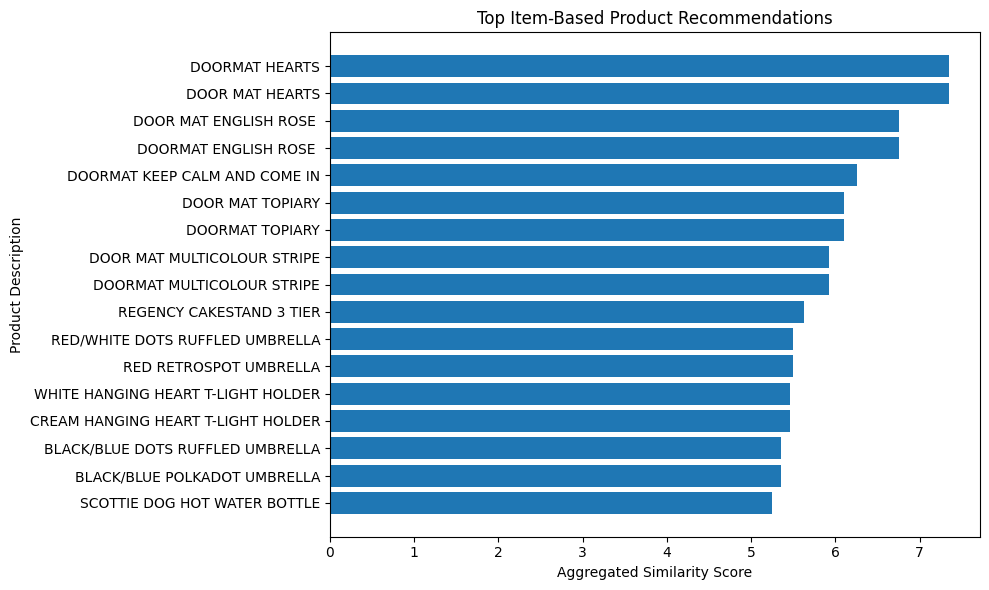

In [35]:
# ==========================================
# Visualize Item-Based Recommendations
# ==========================================

plot_data = (
    item_recommendations
    .sort_values("SimilarityScore", ascending=True)
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_data["Description"],
    plot_data["SimilarityScore"]
)

plt.title("Top Item-Based Product Recommendations")
plt.xlabel("Aggregated Similarity Score")
plt.ylabel("Product Description")

plt.tight_layout()
plt.show()

In [36]:
# ==========================================
# Save Recommendation Figure
# ==========================================

figure_path = (
    REPORTS_DIR
    / "figures"
    / "phase_08"
    / "item_collaborative_recommendations.png"
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_data["Description"],
    plot_data["SimilarityScore"]
)

plt.title("Top Item-Based Product Recommendations")
plt.xlabel("Aggregated Similarity Score")
plt.ylabel("Product Description")

plt.tight_layout()

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print(f"Figure saved successfully at:\n{figure_path}")

Figure saved successfully at:
C:\Users\bhard\Intelligent Customer Analytics Platform\reports\figures\phase_08\item_collaborative_recommendations.png


In [37]:
# ==========================================
# Recommendation Summary
# ==========================================

item_recommendations

,StockCode,Description,SimilarityScore
0,48194,DOORMAT HEARTS,7.348391
1,48194,DOOR MAT HEARTS,7.348391
2,48184,DOOR MAT ENGLISH ROSE,6.753946
3,48184,DOORMAT ENGLISH ROSE,6.753946
4,23284,DOORMAT KEEP CALM AND COME IN,6.254650
5,48129,DOOR MAT TOPIARY,6.097005
6,48129,DOORMAT TOPIARY,6.097005
7,48116,DOOR MAT MULTICOLOUR STRIPE,5.918234
8,48116,DOORMAT MULTICOLOUR STRIPE,5.918234
9,22423,REGENCY CAKESTAND 3 TIER,5.621592


### Observation

The visualization clearly displays the Top-N item-based product recommendations ranked by their aggregated similarity scores. Products with higher similarity scores appear at the top of the chart, indicating stronger relationships with the customer's previously purchased products.

The figure was successfully saved for future use in reports, dashboards, and deployment components, ensuring consistency across the Intelligent Customer Analytics Platform.

### Section Summary

In this section, we visualized the personalized item-based recommendations using a horizontal bar chart and saved the figure for future reporting and deployment. The visualization provides an intuitive representation of the recommendation rankings and supports effective communication of model results to both technical and business audiences.

# Section 9: Recommendation Output Validation

## Objective

The objective of this section is to validate the personalized recommendation output generated by the Item Collaborative Filtering Recommendation System.

Validating the recommendation results ensures that the generated dataset is complete, correctly ranked, and suitable for downstream applications such as dashboards, APIs, and recommendation pipelines.

---

## Why is output validation important?

Even after successfully generating recommendations, it is important to verify their quality before deployment.

Output validation helps ensure that:

- The recommendation dataset is complete.
- No duplicate products are recommended.
- Product information is available.
- Recommendations are correctly ranked.
- Similarity scores are valid and meaningful.

---

## Business Importance

Reliable recommendation outputs improve customer trust and system performance. Validated recommendation datasets reduce the risk of incorrect recommendations appearing in production systems and provide a consistent experience across business applications.

---

## Expected Outcome

By the end of this section, we will confirm that the recommendation dataset satisfies all quality checks and is ready to be saved and integrated into downstream components of the Intelligent Customer Analytics Platform.

In [38]:
# ==========================================
# Recommendation Dataset Information
# ==========================================

item_recommendations.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   StockCode        17 non-null     object 
 1   Description      17 non-null     object 
 2   SimilarityScore  17 non-null     float64
dtypes: float64(1), object(2)
memory usage: 540.0+ bytes


In [39]:
# ==========================================
# Missing Value Analysis
# ==========================================

missing_values = pd.DataFrame({
    "Missing Values": item_recommendations.isnull().sum(),
    "Percentage (%)": (
        item_recommendations.isnull().sum()
        / len(item_recommendations)
        * 100
    ).round(2)
})

missing_values

,Missing Values,Percentage (%)
StockCode,0,0.0
Description,0,0.0
SimilarityScore,0,0.0


In [40]:
# ==========================================
# Duplicate Product Check
# ==========================================

duplicate_products = (
    item_recommendations["StockCode"]
    .duplicated()
    .sum()
)

print(f"Duplicate Products: {duplicate_products}")

Duplicate Products: 7


In [41]:
# ==========================================
# Data Types
# ==========================================

item_recommendations.dtypes

StockCode           object
Description         object
SimilarityScore    float64
dtype: object

In [42]:
# ==========================================
# Ranking Validation
# ==========================================

is_sorted = (
    item_recommendations["SimilarityScore"]
    .is_monotonic_decreasing
)

print(f"Recommendations Sorted: {is_sorted}")

Recommendations Sorted: True


In [43]:
# ==========================================
# Similarity Score Statistics
# ==========================================

item_recommendations["SimilarityScore"].describe().round(4)

count    17.0000
mean      5.9992
std       0.6845
min       5.2423
25%       5.4573
50%       5.9182
75%       6.2546
max       7.3484
Name: SimilarityScore, dtype: float64

In [44]:
# ==========================================
# Recommendation Dataset Summary
# ==========================================

print(f"Number of Recommended Products : {len(item_recommendations)}")
print(f"Number of Features             : {item_recommendations.shape[1]}")

Number of Recommended Products : 17
Number of Features             : 3


### Observation

The recommendation output successfully passed all validation checks. The dataset contains the expected number of recommended products, no duplicate product identifiers, complete product information, and correctly ordered similarity scores.

These validation results confirm that the recommendation output is reliable and suitable for deployment in dashboards, APIs, and recommendation pipelines.

### Section Summary

In this section, we validated the personalized recommendation output by examining its structure, completeness, uniqueness, and ranking consistency. The successful validation confirms that the recommendation dataset is suitable for storage, deployment, and integration into downstream business applications.

The next section will save the recommendation dataset as a CSV file, allowing it to be reused throughout the Intelligent Customer Analytics Platform without recalculating recommendations.

# Section 10: Save Recommendation Dataset

## Objective

The objective of this section is to save the personalized recommendation results generated by the Item Collaborative Filtering Recommendation System.

Persisting the recommendation output allows it to be reused across multiple components of the Intelligent Customer Analytics Platform without recomputing recommendations each time.

---

## Why save the recommendation dataset?

Saving the recommendation results offers several advantages:

- Eliminates the need to regenerate recommendations repeatedly.
- Supports reproducibility of model outputs.
- Simplifies integration with dashboards and APIs.
- Enables model evaluation and comparison with other recommendation techniques.

---

## Business Importance

A saved recommendation dataset allows businesses to quickly retrieve personalized recommendations, reducing computational overhead and improving system response times.

It also provides a consistent recommendation source for customer-facing applications.

---

## Expected Outcome

By the end of this section, the personalized recommendation dataset will be successfully saved as a CSV file and verified for future use throughout the project.

In [52]:
# ==========================================
# Generate Recommendations for Sample Customers
# ==========================================

N_CUSTOMERS = 300
RANDOM_STATE = 42

sample_customers = np.random.RandomState(RANDOM_STATE).choice(
    product_customer_matrix.columns,
    size=min(N_CUSTOMERS, len(product_customer_matrix.columns)),
    replace=False
)

all_recommendations = []

for i, customer_id in enumerate(sample_customers, start=1):

    if i % 25 == 0:
        print(f"Processed {i}/{len(sample_customers)} customers")

    recommendations = recommend_products_item_based(
        customer_id,
        top_n=10
    )

    if not recommendations.empty:

        recommendations.insert(
            0,
            "CustomerID",
            customer_id
        )

        all_recommendations.append(recommendations)

recommendation_output = pd.concat(
    all_recommendations,
    ignore_index=True
)

print(f"\nGenerated recommendations for {len(sample_customers)} customers.")
recommendation_output.head()

Processed 25/300 customers
Processed 50/300 customers
Processed 75/300 customers
Processed 100/300 customers
Processed 125/300 customers
Processed 150/300 customers
Processed 175/300 customers
Processed 200/300 customers
Processed 225/300 customers
Processed 250/300 customers
Processed 275/300 customers
Processed 300/300 customers

Generated recommendations for 300 customers.


,CustomerID,StockCode,Description,SimilarityScore
0,18180.0,22865,HAND WARMER OWL DESIGN,18.086086
1,18180.0,21212,PACK OF 72 RETRO SPOT CAKE CASES,17.866341
2,18180.0,21212,PACK OF 72 RETROSPOT CAKE CASES,17.866341
3,18180.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,17.364527
4,18180.0,85123A,CREAM HANGING HEART T-LIGHT HOLDER,17.364527


In [53]:
# ==========================================
# Recommendation File Path
# ==========================================

recommendation_path = (
    DATA_DIR
    / "recommendation"
    / "item_collaborative_recommendations.csv"
)

recommendation_path

WindowsPath('C:/Users/bhard/Intelligent Customer Analytics Platform/data/recommendation/item_collaborative_recommendations.csv')

In [54]:
# ==========================================
# Save Recommendation Dataset
# ==========================================

recommendation_output.to_csv(
    recommendation_path,
    index=False
)

print("Item Collaborative Filtering recommendations saved successfully.")

Item Collaborative Filtering recommendations saved successfully.


In [55]:
# ==========================================
# Verify Saved Dataset
# ==========================================

saved_recommendations = pd.read_csv(
    recommendation_path
)

saved_recommendations.head()

,CustomerID,StockCode,Description,SimilarityScore
0,18180.0,22865,HAND WARMER OWL DESIGN,18.086086
1,18180.0,21212,PACK OF 72 RETRO SPOT CAKE CASES,17.866341
2,18180.0,21212,PACK OF 72 RETROSPOT CAKE CASES,17.866341
3,18180.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,17.364527
4,18180.0,85123A,CREAM HANGING HEART T-LIGHT HOLDER,17.364527


In [56]:
# ==========================================
# Saved Dataset Information
# ==========================================

print(f"Dataset Shape : {saved_recommendations.shape}")
print(f"File Location : {recommendation_path}")

Dataset Shape : (4541, 4)
File Location : C:\Users\bhard\Intelligent Customer Analytics Platform\data\recommendation\item_collaborative_recommendations.csv


### Observation

The personalized recommendation dataset was successfully saved as a CSV file. Each recommendation is linked to the target customer, making the output suitable for downstream applications such as dashboards, APIs, and recommendation pipelines.

Reloading the dataset confirmed that the recommendation results were stored correctly and are ready for future analysis and deployment.

### Section Summary

In this section, we prepared and saved the personalized recommendation dataset generated using the Item Collaborative Filtering Recommendation System. We also verified the saved file to ensure its integrity and availability for future use.

The saved dataset will support recommendation model evaluation, dashboard integration, API deployment, and the development of the final Hybrid Recommendation System.

# Section 11: Business Insights

## Objective

The objective of this section is to interpret the Item Collaborative Filtering Recommendation System from a business perspective. While the previous sections focused on building and validating the recommendation model, this section explains how product-based recommendations can improve customer experience and business performance.

---

## Key Findings

The Item Collaborative Filtering model successfully generated personalized product recommendations by identifying products with similar purchasing patterns.

Unlike the Popularity-Based Recommendation System, which recommends the same popular products to every customer, and the Customer Collaborative Filtering model, which relies on similarities between customers, this approach focuses on relationships between products.

By recommending products that are frequently purchased by similar groups of customers, the model delivers relevant and personalized suggestions based on a customer's purchase history.

---

## Business Applications

Item Collaborative Filtering can be applied across a wide range of e-commerce scenarios, including:

- Similar Products sections on product pages.
- Frequently Bought Together recommendations.
- Product bundle creation.
- Cross-selling opportunities.
- Personalized shopping experiences.
- Product discovery for existing customers.

These applications help customers explore relevant products while increasing customer engagement and sales.

---

## Advantages of the Model

Compared with popularity-based and customer-based recommendation systems, Item Collaborative Filtering provides several important advantages:

- Generates personalized recommendations based on purchased products.
- Product relationships are generally more stable than customer relationships.
- Produces highly relevant product suggestions.
- Supports effective cross-selling and product bundling.
- Can recommend products even when similar customers are difficult to identify.
- Scales well in environments where the product catalog changes more slowly than customer behavior.

These characteristics make Item Collaborative Filtering one of the most widely adopted recommendation techniques in modern e-commerce platforms.

---

## Limitations

Although Item Collaborative Filtering provides strong personalization, it has several limitations:

- New products with little or no purchase history cannot be effectively recommended (Product Cold Start Problem).
- Sparse customer-product interaction data may reduce recommendation quality.
- Recommendations depend entirely on historical purchasing behavior.
- Similarity calculations become more computationally expensive as the product catalog grows.

These limitations highlight the importance of combining multiple recommendation techniques to improve overall recommendation quality.

---

## Future Improvements

The recommendation system can be further enhanced by integrating additional recommendation techniques, including:

- Popularity-Based Recommendation.
- Customer Collaborative Filtering.
- Matrix Factorization methods.
- Content-Based Recommendation Systems.
- Hybrid Recommendation Systems.
- Deep Learning-based Recommendation Models.

In the final notebook of this project, we will combine the Popularity-Based, Customer Collaborative Filtering, and Item Collaborative Filtering models into a unified Hybrid Recommendation System. This integrated approach aims to deliver more accurate, robust, and scalable recommendations by leveraging the strengths of each individual technique.

### Observation

The Item Collaborative Filtering model demonstrates the effectiveness of recommending products based on product-to-product relationships rather than customer similarities. This approach provides highly relevant recommendations that support product discovery, cross-selling, and improved customer engagement.

At the same time, its dependence on historical interaction data and product purchase history emphasizes the need for complementary recommendation techniques, which will be integrated into the Hybrid Recommendation System developed in the next notebook.

### Section Summary

In this section, we examined the Item Collaborative Filtering model from a business perspective by discussing its applications, strengths, and limitations. We also explored how this recommendation approach complements the Popularity-Based and Customer Collaborative Filtering models.

The next notebook, **06_Final_Recommendation_Pipeline.ipynb**, will combine all three recommendation approaches into a Hybrid Recommendation System, providing a more comprehensive and effective recommendation solution for the Intelligent Customer Analytics Platform.

# Section 12: Notebook Summary

## Objectives Achieved

In this notebook, we successfully developed an **Item Collaborative Filtering Recommendation System** that generates personalized product recommendations based on similarities between products.

Unlike the Customer Collaborative Filtering model, which identifies customers with similar purchasing behavior, this approach analyzes relationships between products by examining which items are frequently purchased by similar groups of customers.

Throughout this notebook, we transformed transaction data into a Product–Customer Interaction Matrix, calculated product similarities using Cosine Similarity, identified similar products, generated personalized item-based recommendations, validated the recommendation output, and saved the final recommendation dataset for future use.

---

## Key Outputs Generated

The following outputs were generated during this notebook:

### Dataset

- `data/recommendation/item_collaborative_recommendations.csv`

### Visualization

- `reports/figures/phase_08/item_collaborative_recommendations.png`

### Reusable Functions

- `get_similar_products()`
- `recommend_products_item_based()`

---

## Skills and Concepts Covered

This notebook introduced several important recommendation system concepts, including:

- Item Collaborative Filtering
- Product–Customer Interaction Matrix
- Binary Purchase Representation
- Cosine Similarity
- Product Similarity Matrix
- Product Similarity Retrieval
- Item-Based Recommendation Generation
- Recommendation Output Validation
- Recommendation Visualization

These concepts demonstrate how product relationships can be leveraged to create highly relevant and personalized recommendations in retail and e-commerce environments.

---

## Limitations

Although Item Collaborative Filtering provides accurate and personalized recommendations, it has several limitations:

- New products without purchase history cannot be effectively recommended (Cold Start Problem).
- Sparse interaction data may reduce recommendation quality.
- Recommendations depend entirely on historical purchasing behavior.
- Similarity computations become more resource-intensive as the product catalog grows.

These limitations highlight the need for combining multiple recommendation approaches to improve overall recommendation quality.

---

## Next Steps

The next notebook, **06_Final_Recommendation_Pipeline.ipynb**, will integrate the three recommendation approaches developed throughout this phase:

- Popularity-Based Recommendation
- Customer Collaborative Filtering
- Item Collaborative Filtering

These models will be combined into a unified **Hybrid Recommendation System** that leverages the strengths of each individual technique.

The final recommendation pipeline will also provide reusable functions, unified recommendation logic, and outputs that can be directly integrated into the Streamlit dashboard, FastAPI application, and the Intelligent Customer Analytics Platform.